In [237]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


X shape: (2000, 2)
y shape: (2000,)
First 5 X:
 [[ 1.7765071   0.19275202]
 [ 0.39780872  0.93039011]
 [ 0.49530794 -0.31832132]
 [-0.94894379  0.16301974]
 [ 0.48495693 -0.33816023]]
First 5 y:
 [1 0 1 0 1]


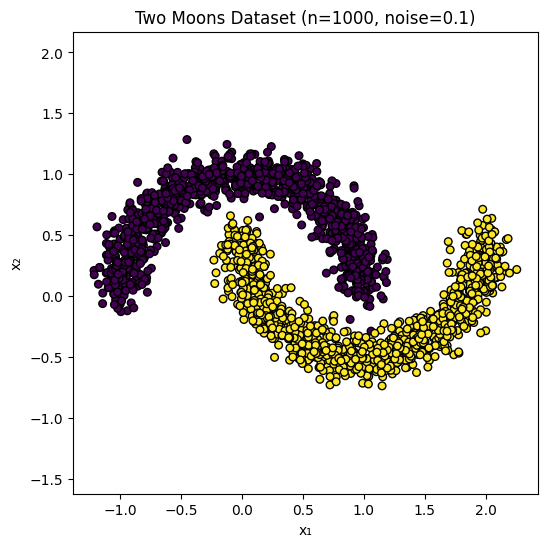

In [238]:
#  Generate data
X, y = make_moons(n_samples=2000, noise=0.1, random_state=42)
# Inspect shapes and first few rows
print("X shape:", X.shape)   
print("y shape:", y.shape)   
print("First 5 X:\n", X[:5])
print("First 5 y:\n", y[:5])

plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=30)
plt.title("Two Moons Dataset (n=1000, noise=0.1)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.axis("equal")
plt.show()

# Define the coupling layer

In [239]:

class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim):
        """
        dim: input dimension (2)
        hidden_dim: size of the hidden layer in the small MLPs
        """
        super().__init__()
        # Split dimension in half
        self.D1 = dim // 2
        self.D2 = dim - self.D1

        # Scale network: x_A -> s(x_A)
        self.scale_net = nn.Sequential(
            nn.Linear(self.D1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.D2)
        )
        # Shift network: x_A -> t(x_A)
        self.shift_net = nn.Sequential(
            nn.Linear(self.D1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.D2)
        )

    def forward(self, x):
        # split features
        x_A = x[:, :self.D1]   
        x_B = x[:, self.D1:]  

        # compute scale and shift
        s = self.scale_net(x_A)  
        t = self.shift_net(x_A)   

        # affine transform on x_B
        y_A = x_A
        y_B = x_B * torch.exp(s) + t

        # log-determinant of Jacobian = sum of s
        log_det = s.sum(dim=1)    # one value per sample

        # recombine and return
        y = torch.cat([y_A, y_B], dim=1)
        return y, log_det

    def inverse(self, y):
        y_A = y[:, :self.D1]
        y_B = y[:, self.D1:]
        s = self.scale_net(y_A)
        t = self.shift_net(y_A)
        x_A = y_A
        x_B = (y_B - t) * torch.exp(-s)
        x = torch.cat([x_A, x_B], dim=1)
        return x

class Permutation(nn.Module):
    def __init__(self, dim):
        super().__init__()
        idx = torch.arange(dim-1, -1, -1)
        self.register_buffer('perm', idx)

    def forward(self, x):
        return x[:, self.perm]

    def inverse(self, x):
        return x[:, self.perm]

In [240]:
class RealNVPFlow(nn.Module):
    def __init__(self, dim, hidden_dim, n_layers=4):
        super().__init__()
        layers = []
        for _ in range(n_layers):
            layers.append(CouplingLayer(dim, hidden_dim))
            layers.append(Permutation(dim))
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        log_det_sum = x.new_zeros(x.size(0))
        for layer in self.layers:
            if isinstance(layer, CouplingLayer):
                x, ld = layer(x)
                log_det_sum += ld
            else:
                x = layer(x)
        return x, log_det_sum

    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x

# Train

In [241]:

# Prepare two‑moons data 
X_np, _ = make_moons(n_samples=2000, noise=0.1, random_state=42)
X = torch.from_numpy(X_np).float()
dataset = TensorDataset(X)
loader  = DataLoader(dataset, batch_size=64, shuffle=True)


#  Instantiate model & optimizer 
flow      = RealNVPFlow(dim=2, hidden_dim=32, n_layers=4)
optimizer = optim.Adam(flow.parameters(), lr=1e-3)

n_epochs     = 100
loss_history = []

for epoch in range(1, n_epochs + 1):
    epoch_loss = 0.0
    for (batch_X,) in loader:
        # forward: x -> z
        z, log_det = flow(batch_X)
        # compute log p_Z(z) for D=2
        log_pz = -0.5 * (z.pow(2).sum(dim=1) + 2 * math.log(2 * math.pi))
        # negative log‑likelihood
        loss = - (log_pz + log_det).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    avg_nll = epoch_loss / len(loader.dataset)
    loss_history.append(avg_nll)
    print(f"Epoch {epoch:3d}  NLL = {avg_nll:.4f}")



Epoch   1  NLL = 2.8603
Epoch   2  NLL = 1.9755
Epoch   3  NLL = 1.8353
Epoch   4  NLL = 1.7672
Epoch   5  NLL = 1.7311
Epoch   6  NLL = 1.7093
Epoch   7  NLL = 1.6849
Epoch   8  NLL = 1.6619
Epoch   9  NLL = 1.6367
Epoch  10  NLL = 1.6048
Epoch  11  NLL = 1.5751
Epoch  12  NLL = 1.5508
Epoch  13  NLL = 1.5295
Epoch  14  NLL = 1.5204
Epoch  15  NLL = 1.5028
Epoch  16  NLL = 1.4850
Epoch  17  NLL = 1.4737
Epoch  18  NLL = 1.4476
Epoch  19  NLL = 1.4664
Epoch  20  NLL = 1.4593
Epoch  21  NLL = 1.4069
Epoch  22  NLL = 1.4355
Epoch  23  NLL = 1.3829
Epoch  24  NLL = 1.3844
Epoch  25  NLL = 1.3735
Epoch  26  NLL = 1.3894
Epoch  27  NLL = 1.4594
Epoch  28  NLL = 1.3983
Epoch  29  NLL = 1.3601
Epoch  30  NLL = 1.3404
Epoch  31  NLL = 1.3414
Epoch  32  NLL = 1.3145
Epoch  33  NLL = 1.3010
Epoch  34  NLL = 1.3127
Epoch  35  NLL = 1.3005
Epoch  36  NLL = 1.2976
Epoch  37  NLL = 1.2783
Epoch  38  NLL = 1.2779
Epoch  39  NLL = 1.2617
Epoch  40  NLL = 1.2800
Epoch  41  NLL = 1.2571
Epoch  42  NLL =

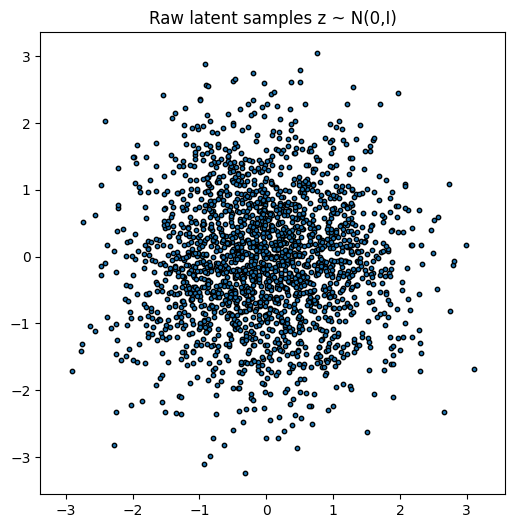

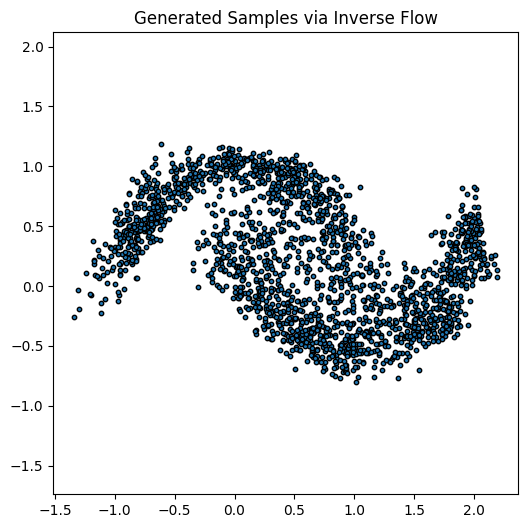

In [242]:

# Ensure model is in eval mode
flow.eval()

# Sample latent points z ~ N(0, I)
num_samples = 2000
z_sample = torch.randn(num_samples, 2)

# Invert through the flow to get generated x
with torch.no_grad():
    x_gen = flow.inverse(z_sample)

# view the raw latent samples
z_np = z_sample.numpy()
plt.figure(figsize=(6,6))
plt.scatter(z_np[:,0], z_np[:,1], s=10, edgecolor='k')
plt.title("Raw latent samples z ~ N(0,I)")
plt.axis('equal')
plt.show()

# Generated data from z
x_np = x_gen.detach().cpu().numpy()
plt.figure(figsize=(6,6))
plt.scatter(x_np[:,0], x_np[:,1], s=10, edgecolor='k')
plt.title("Generated Samples via Inverse Flow")
plt.axis('equal')
plt.show()


In [243]:
flow.eval()

# Forward pass:
with torch.no_grad():
    z, log_det = flow(X)
print("z shape:", z.shape)
print("First 5 z’s:\n", z[:5])

z shape: torch.Size([2000, 2])
First 5 z’s:
 tensor([[ 1.0976,  0.2089],
        [-0.1361,  0.5599],
        [ 0.1193, -1.0784],
        [-1.3493,  0.8786],
        [ 0.1171, -1.1754]])
